<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/ML_Exp07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🧠 Unsupervised Learning and Clustering**

**Unsupervised learning** is a type of machine learning where the algorithm is **not provided with labeled data**. Instead, it tries to discover hidden patterns, structures, or relationships within the input data.  

One of the key tasks in unsupervised learning is **clustering**, which involves grouping data points such that points in the same cluster are more similar to each other than to points in other clusters.

## **Clustering Methods in This Report**

This report focuses on three clustering methods applied to the **Iris dataset**:

1. **MST (Minimum Spanning Tree) Clustering**  
   - A **graph-based method** that connects points to form a minimum spanning tree using distances.  
   - Clusters are formed by **cutting the longest edges** in the tree, separating dense regions.  
   - Works well for **irregular and non-spherical clusters**.

2. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**  
   - A **density-based method** that groups points based on density.  
   - Identifies **core points, border points, and noise points**, allowing detection of outliers.  
   - Can find clusters of **arbitrary shapes** and does **not require specifying the number of clusters**.

3. **EM (Expectation-Maximization with Gaussian Mixture Models)**  
   - A **probabilistic model-based method** that assumes data is generated from a mixture of Gaussian distributions.  
   - Iteratively performs **Expectation** (soft cluster assignment) and **Maximization** (update parameters) steps.  
   - Suitable for **overlapping clusters** and provides **probabilistic cluster memberships**.




# **📊 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

DBSCAN is a **density-based clustering algorithm** that groups together points that are close to each other based on a distance metric and a minimum number of points.  
It can also detect **outliers (noise points)** and identify clusters of **arbitrary shapes**, unlike K-Means which assumes spherical clusters.

### **✅ Key Parameters:**
- **`eps`**: Maximum distance between two points for them to be considered as neighbors.
- **`min_samples`**: Minimum number of points required to form a dense region.

### **✅ Types of Points:**
- **Core Points:** Have at least `min_samples` neighbors within `eps`.
- **Border Points:** Fewer neighbors but lie within the neighborhood of a core point.
- **Noise Points:** Not part of any cluster.

**Advantages:**
- Detects arbitrary shaped clusters.
- Identifies noise/outliers.
- No need to specify number of clusters in advance.

**Disadvantages:**
- Sensitive to `eps` and `min_samples` values.
- Performance can degrade with varying density data.

---

## **📥 Step 1: Load the Iris Dataset**

In this step, we load the **Iris dataset**, a well-known dataset used for classification and clustering tasks.  
It contains **150 samples** of iris flowers with **4 numerical features**:
- Sepal length  
- Sepal width  
- Petal length  
- Petal width  

We will create a DataFrame for easier manipulation and visualization.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score, completeness_score

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# If dataset has an 'id' column, simulate it (for demonstration)
df['id'] = range(1, len(df) + 1)

# Display first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,id
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,3
3,4.6,3.1,1.5,0.2,0,4
4,5.0,3.6,1.4,0.2,0,5


## **🔎 Step 2: Drop Class Label and ID Column**

Since we are performing **unsupervised learning**, we must **not include any labels** or non-feature columns during clustering.

- **`target` column:** Contains class labels (Setosa, Versicolor, Virginica) – we drop it because clustering should not use labels.
- **`id` column:** A unique identifier with no relation to the feature space – it must also be removed.

We will store the original `target` values separately for evaluation purposes after clustering.


In [ ]:
# Drop class label and ID column before clustering
X = df.drop(['target', 'id'], axis=1)

# Store original labels separately for evaluation
y_true = df['target']

## **⚙️ Step 3: Data Preprocessing (Standardization)**

Clustering algorithms, especially distance-based ones like DBSCAN, are sensitive to the scale of data.  
Therefore, we **standardize** the features using `StandardScaler` to bring all features to a similar scale (mean = 0, variance = 1).

This ensures that no single feature dominates the distance calculation due to its larger numeric range.


In [ ]:
# Standardize the features for better performance of distance-based algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the scaled data shape
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (150, 4)


## **🤖 Step 4: Apply DBSCAN Algorithm**

We now apply the **DBSCAN** clustering algorithm to the preprocessed data.

Steps:
1. Initialize DBSCAN with `eps` and `min_samples`.
2. Fit the model to the scaled data.
3. Predict cluster labels for each data point.

The output will include:
- Cluster labels (e.g., 0, 1, 2...)
- `-1` label for **noise points** that do not belong to any cluster.

In [ ]:
# Initialize DBSCAN with chosen parameters
dbscan = DBSCAN(eps=0.45, min_samples=5)

# Fit the model and predict cluster labels
y_dbscan = dbscan.fit_predict(X_scaled)

# Unique cluster labels
unique_clusters = np.unique(y_dbscan)
print("Cluster labels found (including noise -1):", unique_clusters)

Cluster labels found (including noise -1): [-1  0  1  2]


## **📈 Step 5: Visualizing DBSCAN Clusters**

To better understand how DBSCAN has grouped the Iris dataset, we create a **2D scatter plot** using the first two standardized features:

- **Clustered Points:** Displayed in distinct colors corresponding to their assigned cluster.
- **Noise Points:** Labeled `-1` by DBSCAN and plotted as **black crosses (✕)** to highlight outliers.
- A **colorbar** is included to show cluster label numbers for easier interpretation.

This visualization allows us to observe the shape, density, and separation of clusters as identified by DBSCAN.


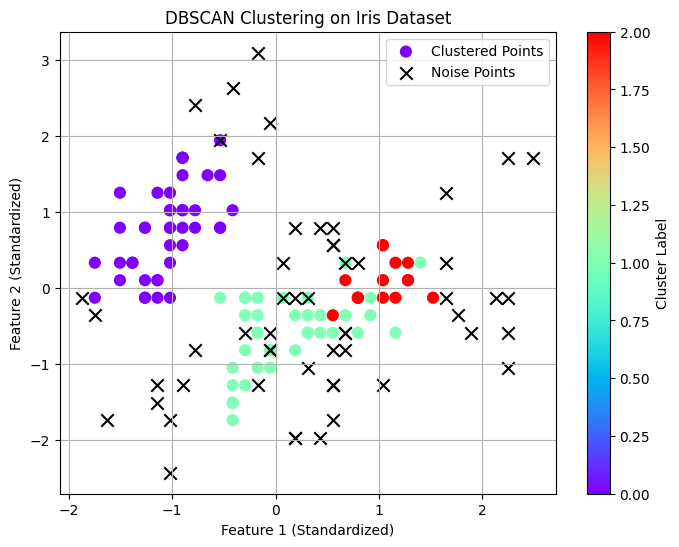

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Separate noise and cluster points
core_points = X_scaled[y_dbscan != -1]       # Cluster points
core_labels = y_dbscan[y_dbscan != -1]

noise_points = X_scaled[y_dbscan == -1]      # Noise points

# Plot cluster points
plt.figure(figsize=(8,6))
scatter = plt.scatter(core_points[:, 0], core_points[:, 1],
                      c=core_labels, cmap='rainbow', s=60, label='Clustered Points')

# Plot noise points as crosses
if len(noise_points) > 0:
    plt.scatter(noise_points[:, 0], noise_points[:, 1],
                c='black', marker='x', s=80, label='Noise Points')

# Add title and labels
plt.title("DBSCAN Clustering on Iris Dataset")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.grid(True)

# Add legend
plt.legend()

# Add colorbar for cluster labels
plt.colorbar(scatter, label='Cluster Label')

plt.show()

## **📊 Step 6: Evaluating DBSCAN Clustering Performance**

To assess the quality of the clusters formed by **DBSCAN**, several clustering evaluation metrics are computed:

- **Silhouette Score:**  
  Measures how well-separated and cohesive the clusters are (range: -1 to +1).  
  A higher value indicates better-defined clusters.  
  *Noise points (`-1` labels) are excluded from this calculation.*

- **Davies–Bouldin Index:**  
  Evaluates intra-cluster similarity and inter-cluster separation.  
  Lower values indicate better clustering performance.

- **Adjusted Rand Index (ARI):**  
  Compares the predicted cluster labels with the true Iris species labels.  
  A value close to **1** indicates high similarity to ground truth.

Additionally, we display:
- The total number of clusters (excluding noise).
- The number of noise points detected by DBSCAN.

These metrics collectively provide a balanced view of clustering performance and data structure.


In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score

# Silhouette Score (exclude noise points)
if len(unique_clusters) > 1 and len(noise_points) < len(X_scaled):
    sil_score = silhouette_score(X_scaled[y_dbscan!=-1], y_dbscan[y_dbscan!=-1])
else:
    sil_score = 'Not defined (single cluster or all noise)'

# Davies-Bouldin Index (exclude noise points)
if len(unique_clusters) > 1:
    db_index = davies_bouldin_score(X_scaled[y_dbscan!=-1], y_dbscan[y_dbscan!=-1])
else:
    db_index = 'Not defined (single cluster)'

# Adjusted Rand Index (compare with true labels)
ari = adjusted_rand_score(y_true, y_dbscan)

# Number of clusters (excluding noise)
num_clusters = len(unique_clusters[unique_clusters != -1])

# Number of noise points
num_noise = len(noise_points)

# Print all results
print("----- DBSCAN Performance Measures -----")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)
print("Adjusted Rand Index:", ari)
print("Number of clusters (excluding noise):", num_clusters)
print("Number of noise points:", num_noise)

----- DBSCAN Performance Measures -----
Silhouette Score: 0.5450207025202175
Davies-Bouldin Index: 0.6593906963332723
Adjusted Rand Index: 0.5171000874898058
Number of clusters (excluding noise): 3
Number of noise points: 54


## **📋 Step 7: Inspecting the Clustered Results**

Finally, we combine the **original feature data**, the **true species labels**, and the **cluster assignments** into a single DataFrame.  
This allows us to easily inspect how the clustering algorithm grouped the samples compared to their true classes.

By displaying the first few rows, we can visually compare:
- The **original Iris features**
- The **actual species label**
- The **predicted cluster label**


In [ ]:
# Combine results into a new DataFrame for inspection
result_df = pd.DataFrame(X, columns=iris.feature_names)
result_df['True Label'] = y_true
result_df['DBSCAN Cluster'] = y_dbscan

# Display sample of clustered results
result_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True Label,DBSCAN Cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
5,5.4,3.9,1.7,0.4,0,0
6,4.6,3.4,1.4,0.3,0,0
7,5.0,3.4,1.5,0.2,0,0
8,4.4,2.9,1.4,0.2,0,0
9,4.9,3.1,1.5,0.1,0,0


# **🌳 Minimum Spanning Tree (MST) Clustering**

MST-based clustering is a **graph-theoretic** method that forms clusters by cutting the heaviest edges in a Minimum Spanning Tree.  
It is particularly useful for identifying **non-spherical** and **unevenly sized** clusters.

**Core Idea:**
- Construct a complete graph of data points where edges represent pairwise distances.
- Compute the **Minimum Spanning Tree (MST)** using algorithms like Kruskal’s or Prim’s.
- Remove the `(k-1)` longest edges to divide the tree into `k` connected components.
- Each connected component forms a **cluster**.

This approach is **non-parametric**, meaning it doesn’t assume a specific distribution or shape of clusters.


In [ ]:
# Import Required Libraries and Load Dataset
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X = iris.data  # features only

# Create DataFrame for clarity
iris_df = pd.DataFrame(X, columns=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'])

print("="*70)
print("MST CLUSTERING ON IRIS DATASET")
print("="*70)
print("\nFirst 5 rows of Iris dataset:")
print(iris_df.head())
print(f"\nDataset shape: {iris_df.shape}")

MST CLUSTERING ON IRIS DATASET

First 5 rows of Iris dataset:
   Sepal Length  Sepal Width  Petal Length  Petal Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Dataset shape: (150, 4)


## **📏 Step 1: Compute Pairwise Distance Matrix**

The first step is to compute the **pairwise Euclidean distances** between all data points.  
This produces a **distance matrix**, where each cell `(i, j)` represents the distance between sample `i` and sample `j`.

This matrix forms the foundation for constructing the MST since each edge’s weight corresponds to a pairwise distance.


In [ ]:
# Compute Pairwise Euclidean Distance Matrix

condensed_dist_matrix = pdist(iris_df, 'euclidean')
dist_matrix = squareform(condensed_dist_matrix)

print("="*70)
print("Pairwise Distance Matrix Stats")
print("="*70)
print(f"Shape: {dist_matrix.shape}")
print(f"Min (non-zero): {dist_matrix[dist_matrix > 0].min():.4f}")
print(f"Max: {dist_matrix.max():.4f}")
print(f"Mean: {dist_matrix[dist_matrix > 0].mean():.4f}")

Pairwise Distance Matrix Stats
Shape: (150, 150)
Min (non-zero): 0.1000
Max: 7.0852
Mean: 2.5449


## **🪜 Step 2: Constructing the Minimum Spanning Tree**

Using the computed distance matrix, we build a **fully connected weighted graph**.  
From this graph, we extract the **Minimum Spanning Tree (MST)** using Kruskal’s algorithm.

The MST:
- Connects all data points.
- Has the minimum total edge weight possible.
- Contains no cycles.


In [ ]:
# Build Minimum Spanning Tree (MST)

G = nx.from_numpy_array(dist_matrix)
mst = nx.minimum_spanning_tree(G)

print("="*70)
print("Minimum Spanning Tree Summary")
print("="*70)
print(f"Nodes: {mst.number_of_nodes()}")
print(f"Edges: {mst.number_of_edges()}")
print(f"Expected (n-1): {len(X) - 1}")
total_weight = sum([d['weight'] for _, _, d in mst.edges(data=True)])
print(f"Total MST Weight: {total_weight:.4f}")

Minimum Spanning Tree Summary
Nodes: 150
Edges: 149
Expected (n-1): 149
Total MST Weight: 43.7884


## **✂️ Step 3: Cutting the Longest Edges to Form Clusters**

To form clusters, we cut the **(k–1) longest edges** of the MST.  
Each remaining connected component becomes a separate cluster.

This works because the longest edges generally connect **different natural groups** in the dataset.


In [ ]:
# Cut Longest Edges to Form k Clusters

k = 3  # desired number of clusters

edges = sorted(mst.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
edges_to_remove = edges[:k - 1]

print("="*70)
print(f"Cutting {k-1} Longest Edges → Form {k} Clusters")
print("="*70)
for i, (u, v, data) in enumerate(edges_to_remove):
    print(f"  {i+1}. Edge ({u}, {v}) — Weight: {data['weight']:.4f}")

mst_forest = mst.copy()
mst_forest.remove_edges_from([(u, v) for u, v, _ in edges_to_remove])

Cutting 2 Longest Edges → Form 3 Clusters
  1. Edge (23, 98) — Weight: 1.6401
  2. Edge (105, 117) — Weight: 0.8185


## **🧩 Step 4: Assigning Cluster Labels**

After removing the longest edges, the resulting disconnected components of the MST form clusters.  
We traverse each connected component and assign a unique cluster label to its nodes.

This labeling step ensures that every data point is associated with a specific cluster.


In [ ]:
# Assign Cluster Labels via Connected Components

components = list(nx.connected_components(mst_forest))
labels = np.zeros(len(X), dtype=int)

for i, comp in enumerate(components):
    for node in comp:
        labels[node] = i
    print(f"Cluster {i}: {len(comp)} points")

print(f"\nTotal clusters formed: {len(components)}")

Cluster 0: 50 points
Cluster 1: 98 points
Cluster 2: 2 points

Total clusters formed: 3


## **📊 Step 5: Cluster Validation Metrics**

To measure the quality of clustering, we compute:
- **Silhouette Score** — Measures how well samples are separated between clusters.
- **Davies–Bouldin Index** — Lower values indicate better clustering.
- **Dunn Index** — Ratio of minimum inter-cluster distance to maximum intra-cluster distance.

Together, these metrics provide an objective assessment of the MST-based clustering performance.


In [ ]:
# Cluster Validation Metrics (Silhouette, DB, Dunn)

def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    clusters = [X[labels == i] for i in unique_labels]
    max_intra = max(np.max(pdist(c)) for c in clusters if len(c) > 1)
    min_inter = min(np.min(distance.cdist(clusters[i], clusters[j]))
                    for i in range(len(clusters)) for j in range(i+1, len(clusters)))
    return min_inter / max_intra if max_intra > 0 else 0

sil_score = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)
dunn = dunn_index(X, labels)

print("="*70)
print("Cluster Validation Metrics")
print("="*70)
print(f"Silhouette Score : {sil_score:.4f}")
print(f"Davies-Bouldin   : {db_index:.4f}")
print(f"Dunn Index        : {dunn:.4f}")

Cluster Validation Metrics
Silhouette Score : 0.5121
Davies-Bouldin   : 0.4472
Dunn Index        : 0.1691


## **🎨 Step 6: Visualizing Clusters with PCA Projection**

We apply **Principal Component Analysis (PCA)** to reduce the dataset to two dimensions.  
This allows visualizing the MST clusters in 2D while retaining most of the data variance.

Each cluster is colored differently, providing an intuitive overview of how MST-based clustering partitions the data.


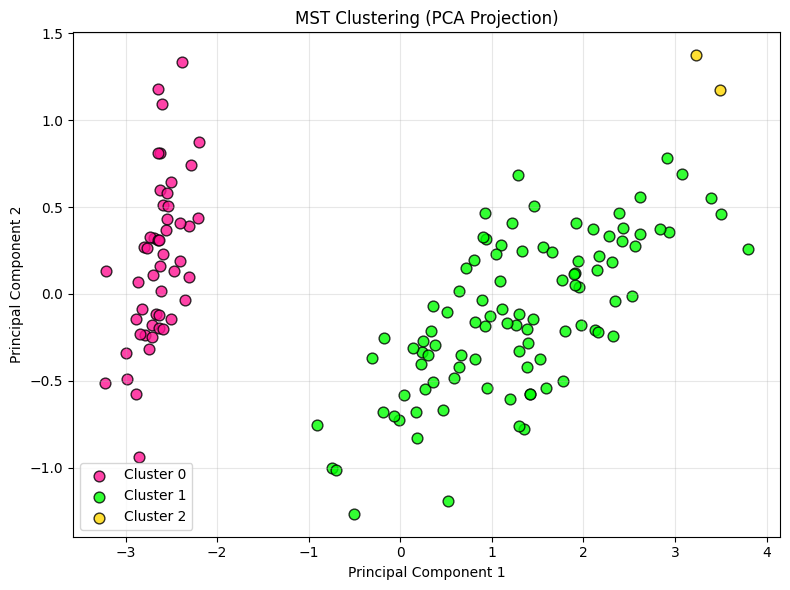

In [ ]:
# PCA Cluster Scatter Plot

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
colors = ['#FF1493', '#00FF00', '#FFD700', '#00BFFF', '#FF4500']

plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1],
                color=colors[i], label=f'Cluster {i}', edgecolor='black', s=60, alpha=0.8)
plt.title("MST Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **🌿 Step 7: Visualizing the Original MST with Cut Edges**

This plot displays the **entire Minimum Spanning Tree** before cutting edges.  
The **red edges** represent the ones removed to create separate clusters.

It helps visually confirm which edges were critical for forming the clusters.


/tmp/ipython-input-1635538743.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


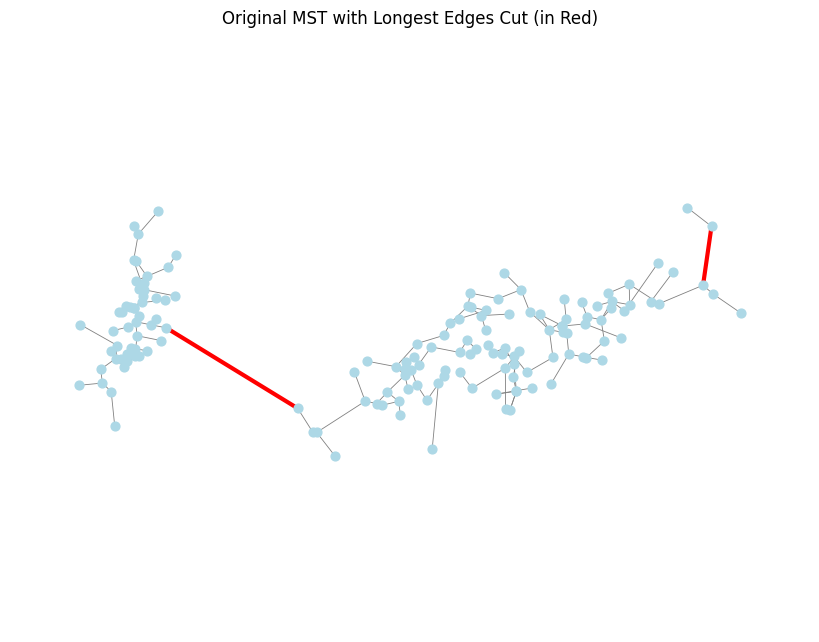

In [ ]:
# Original MST with Cut Edges

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pos = {i: X_pca[i] for i in range(len(X_pca))}

plt.figure(figsize=(8,6))
nx.draw(mst, pos, node_color='lightblue', node_size=40,
        edge_color='gray', width=0.6, with_labels=False)
nx.draw_networkx_edges(mst, pos, edgelist=[(u, v) for u, v, _ in edges_to_remove],
                       width=3, edge_color='red')
plt.title('Original MST with Longest Edges Cut (in Red)')
plt.axis('equal')
plt.tight_layout()
plt.show()

## **🌲 Step 8: Disjoint MST Forest (Cluster Representation)**

After cutting the longest edges, the MST splits into multiple smaller trees — a **forest**.  
Each connected component (tree) corresponds to a distinct cluster.

Nodes are colored based on their assigned cluster labels, illustrating the final clustering structure.


/tmp/ipython-input-980239203.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


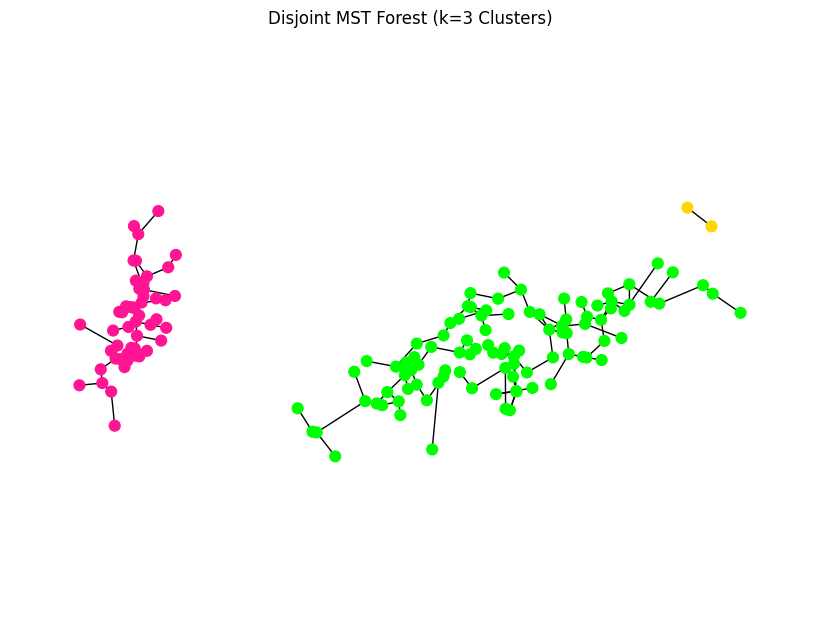

In [ ]:
# Disjoint MST Forest (Clusters)

node_colors = [colors[labels[i]] for i in range(len(labels))]

plt.figure(figsize=(8,6))
nx.draw(mst_forest, pos, node_color=node_colors, node_size=60,
        edge_color='black', width=1.0, with_labels=False)
plt.title(f'Disjoint MST Forest (k={k} Clusters)')
plt.axis('equal')
plt.tight_layout()
plt.show()

# **Gaussian Mixture Model (GMM) Clustering on Iris Dataset**

### Expectation-Maximization (EM) Algorithm
The **EM algorithm** is an iterative method to find maximum likelihood estimates of parameters in probabilistic models with latent variables.  
In **Gaussian Mixture Models (GMM)**, EM is used to:
1. **Expectation (E-step):** Estimate the probability that each data point belongs to each Gaussian component.
2. **Maximization (M-step):** Update the parameters of each Gaussian (mean, covariance, and mixing coefficient) to maximize the likelihood given the probabilities.

GMM allows clusters to have different shapes and sizes, unlike K-Means which assumes spherical clusters of equal variance.


## **Step 1: Import Libraries**

1. `numpy` and `pandas` for data handling.
2. `matplotlib` and `seaborn` for visualization.
3. `StandardScaler` to normalize features.
4. `GaussianMixture` for clustering.
5. `PCA` for reducing dimensions for plotting.
6. Metrics: `silhouette_score`, `davies_bouldin_score`, `adjusted_rand_score`.
7. `load_iris` to access the dataset if needed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Optional: add an ID column
df['id'] = range(1, len(df) + 1)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,id
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,3
3,4.6,3.1,1.5,0.2,0,4
4,5.0,3.6,1.4,0.2,0,5


## **Step 2: Load and Preprocess Data**

1. Drop non-numeric columns (`id`, `target`) to keep only features.
2. Scale features using `StandardScaler` for better clustering performance.
3. Keep true labels (`target`) for evaluation (Adjusted Rand Index) if available.


In [ ]:
# Using existing DataFrame 'df' from previous cells
X = df.drop(['target', 'id'], axis=1)
features = X  # for clarity

# Scale features
scaler = StandardScaler()
Xs = scaler.fit_transform(features)

# True labels for evaluation
try:
    y_true_species = df['target']
except KeyError:
    print("Warning: 'target' column not found in df. Adjusted Rand Index will be skipped.")
    y_true_species = None

## **Step 3: Find Best Covariance Type for GMM**

1. Test different covariance types: `full`, `tied`, `diag`, `spherical`.
2. Fit GMM with 3 clusters (based on Iris dataset nature).
3. Evaluate each model using **Silhouette Score**.
4. Select the covariance type with the highest Silhouette Score as the best model.


In [ ]:
best_score = -1
best_cov = None
best_gmm = None
best_labels = None

n_components_to_test = 3
print(f"Testing GMM with {n_components_to_test} components for different covariance types:")

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    try:
        gmm = GaussianMixture(n_components=n_components_to_test, covariance_type=cov_type,
                              n_init=10, random_state=42)
        labels = gmm.fit_predict(Xs)
        score = silhouette_score(Xs, labels)
        print(f"  Covariance type: {cov_type}, Silhouette Score: {score:.4f}")
        if score > best_score:
            best_score = score
            best_cov = cov_type
            best_gmm = gmm
            best_labels = labels
    except ValueError as e:
         print(f"  Could not fit GMM with covariance type '{cov_type}': {e}")
         continue

print("\n=== Best GMM Model with 3 Clusters ===")
if best_gmm is not None:
    print(f"Covariance Type: {best_cov}")
    print(f"Silhouette Score: {best_score:.4f}")

Testing GMM with 3 components for different covariance types:
  Covariance type: full, Silhouette Score: 0.3742
  Covariance type: tied, Silhouette Score: 0.3910
  Covariance type: diag, Silhouette Score: 0.4135
  Covariance type: spherical, Silhouette Score: 0.4566

=== Best GMM Model with 3 Clusters ===
Covariance Type: spherical
Silhouette Score: 0.4566


## **Step 4: Evaluate the Best GMM**

1. Compute **Davies–Bouldin Index** (lower is better).
2. Calculate **AIC / BIC** for model comparison.
3. Compute **Adjusted Rand Index (ARI)** if true labels are available, to compare clustering quality with actual species.


In [ ]:
if best_gmm is not None:
    try:
        db_index = davies_bouldin_score(Xs, best_labels)
        print(f"Davies–Bouldin Index: {db_index:.4f}")
    except ValueError as e:
        print(f"Could not calculate Davies–Bouldin Index: {e}")

    print(f"AIC: {best_gmm.aic(Xs):.4f}")
    print(f"BIC: {best_gmm.bic(Xs):.4f}")

    # Adjusted Rand Index
    if y_true_species is not None:
        try:
            true_labels_factored = pd.factorize(y_true_species)[0]
            ari = adjusted_rand_score(true_labels_factored, best_labels)
            print(f"Adjusted Rand Index: {ari:.4f}")
        except Exception as e:
            print(f"Could not calculate Adjusted Rand Index: {e}")
    else:
        print("Adjusted Rand Index not calculated (true labels not available).")
else:
    print("No valid GMM model could be fitted.")

Davies–Bouldin Index: 0.8323
AIC: 1175.6820
BIC: 1226.8628
Adjusted Rand Index: 0.6410


## **Step 5: 2D Visualization Using PCA**

1. Reduce data to 2 dimensions using PCA.
2. Plot the 2D scatter plot with clusters colored differently.
3. Helps visualize separation of clusters and interpret results.


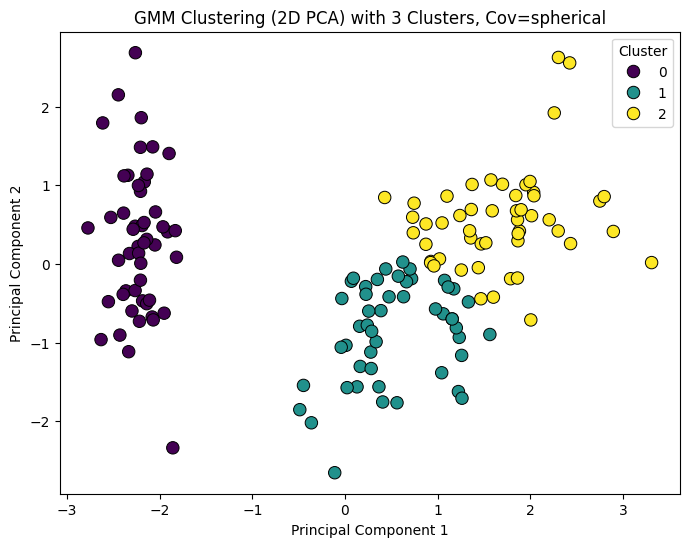

In [ ]:
if best_labels is not None:
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(Xs)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=X_pca2[:,0], y=X_pca2[:,1],
        hue=best_labels, palette='viridis', s=80, edgecolor='k'
    )
    plt.title(f"GMM Clustering (2D PCA) with {n_components_to_test} Clusters, Cov={best_cov}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title='Cluster')
    plt.show()
else:
    print("Skipping 2D visualization as no best GMM model was found.")

## **Step 6: 3D Visualization Using PCA**

1. Reduce data to 3 dimensions using PCA (if ≥3 features).
2. Plot the 3D scatter plot with clusters colored differently.
3. Provides better insight into cluster distribution in higher dimensions.


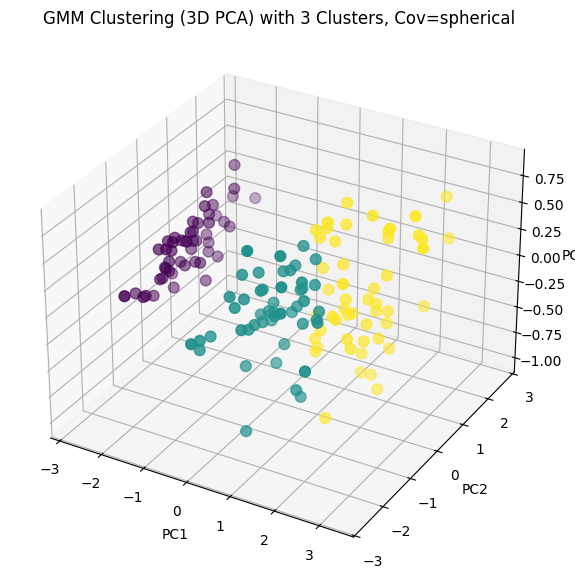

In [ ]:
if best_labels is not None and Xs.shape[1] >= 3:
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(Xs)

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        X_pca3[:,0], X_pca3[:,1], X_pca3[:,2],
        c=best_labels, cmap='viridis', s=60
    )
    ax.set_title(f"GMM Clustering (3D PCA) with {n_components_to_test} Clusters, Cov={best_cov}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.show()
elif Xs.shape[1] < 3:
    print("Skipping 3D visualization as the data has less than 3 features.")
else:
    print("Skipping 3D visualization as no best GMM model was found.")